In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### PCA

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

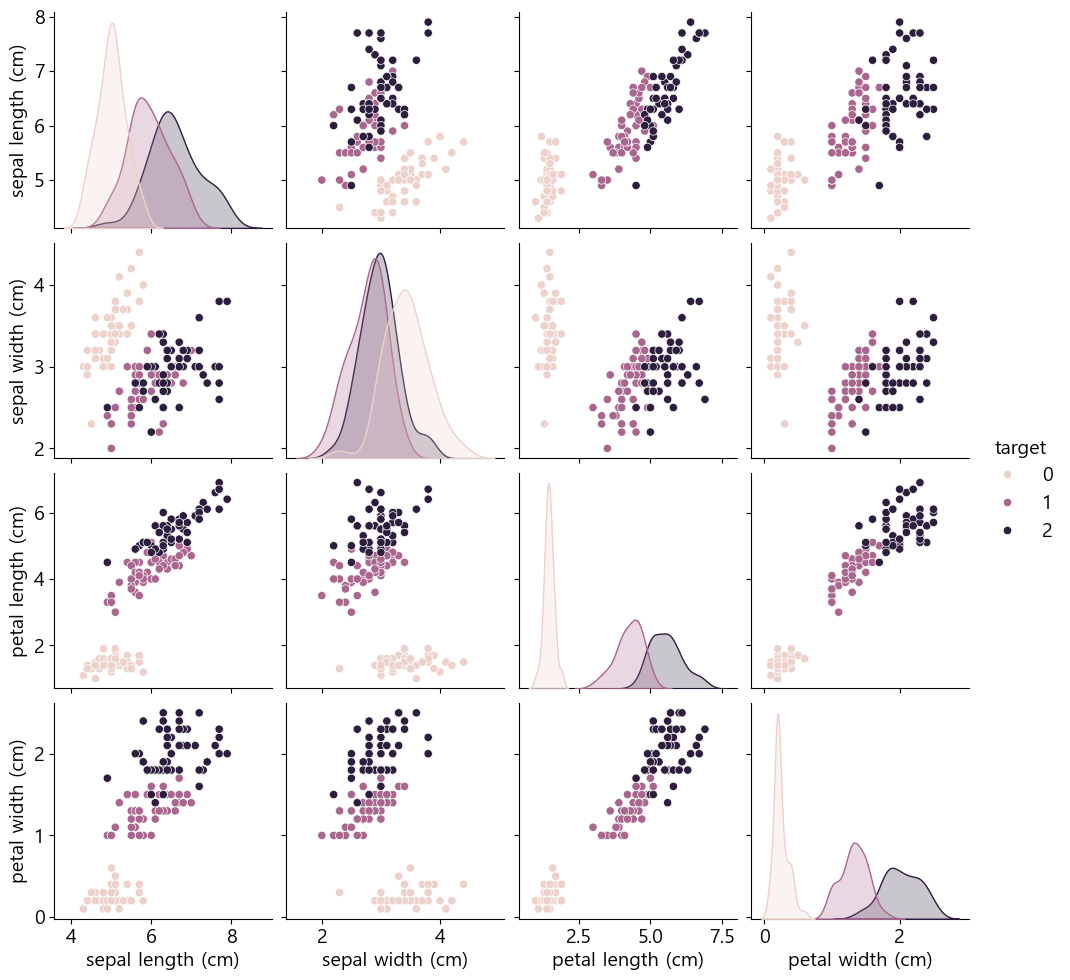

In [3]:
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['target']=y
sns.pairplot(data=iris_df, hue='target')
plt.show()

In [4]:
# 표준화
# 각 특성의 스케일이 다르면 분산 계산에 왜곡이 생기므로 표준화를 진행한다.
# 결과데이터를 주고 학습하는게 아니기 떄문에 분할하지 않음
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# 차원축소
# n_components : 축소 시킬 차원의 개수
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

In [6]:
X_pca[:,0]

array([-2.26470281, -2.08096115, -2.36422905, -2.29938422, -2.38984217,
       -2.07563095, -2.44402884, -2.23284716, -2.33464048, -2.18432817,
       -2.1663101 , -2.32613087, -2.2184509 , -2.6331007 , -2.1987406 ,
       -2.26221453, -2.2075877 , -2.19034951, -1.898572  , -2.34336905,
       -1.914323  , -2.20701284, -2.7743447 , -1.81866953, -2.22716331,
       -1.95184633, -2.05115137, -2.16857717, -2.13956345, -2.26526149,
       -2.14012214, -1.83159477, -2.61494794, -2.44617739, -2.10997488,
       -2.2078089 , -2.04514621, -2.52733191, -2.42963258, -2.16971071,
       -2.28647514, -1.85812246, -2.5536384 , -1.96444768, -2.13705901,
       -2.0697443 , -2.38473317, -2.39437631, -2.22944655, -2.20383344,
        1.10178118,  0.73133743,  1.24097932,  0.40748306,  1.0754747 ,
        0.38868734,  0.74652974, -0.48732274,  0.92790164,  0.01142619,
       -0.11019628,  0.44069345,  0.56210831,  0.71956189, -0.0333547 ,
        0.87540719,  0.35025167,  0.15881005,  1.22509363,  0.16

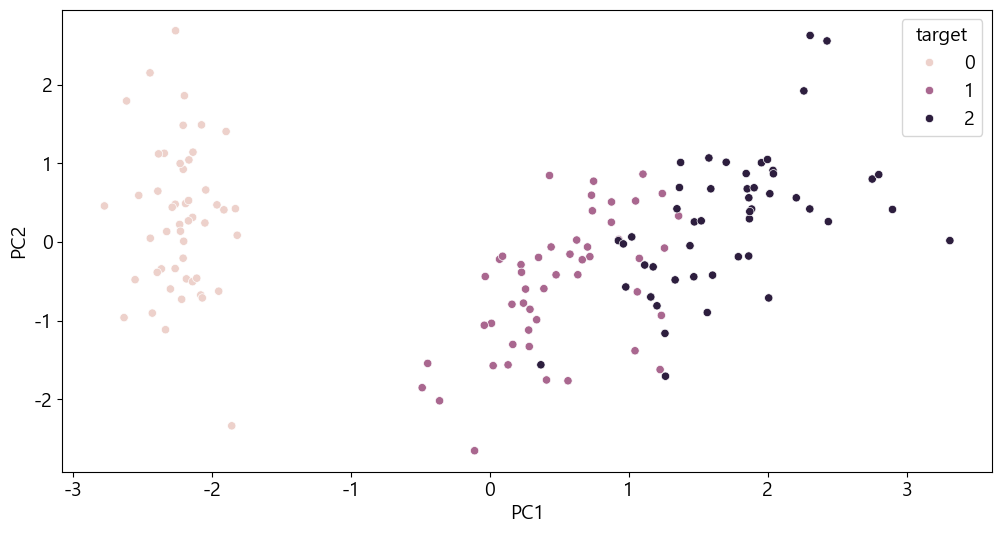

In [7]:
# 시각화 
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y

sns.scatterplot(data=pca_df, x='PC1', y='PC2',hue='target')
plt.show()

### LDA

In [8]:
from sklearn.datasets import load_iris

In [9]:
iris = load_iris()

X = iris.data
y = iris.target

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [12]:
# LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled,y)

In [13]:
# 시각화를 위해 데이터 프레임을 생성한다.
pca_df = pd.DataFrame(X_pca, columns=['C1','C2'])
pca_df['target'] = y

lda_df = pd.DataFrame(X_lda, columns=['C1','C2'])
lda_df['target'] = y

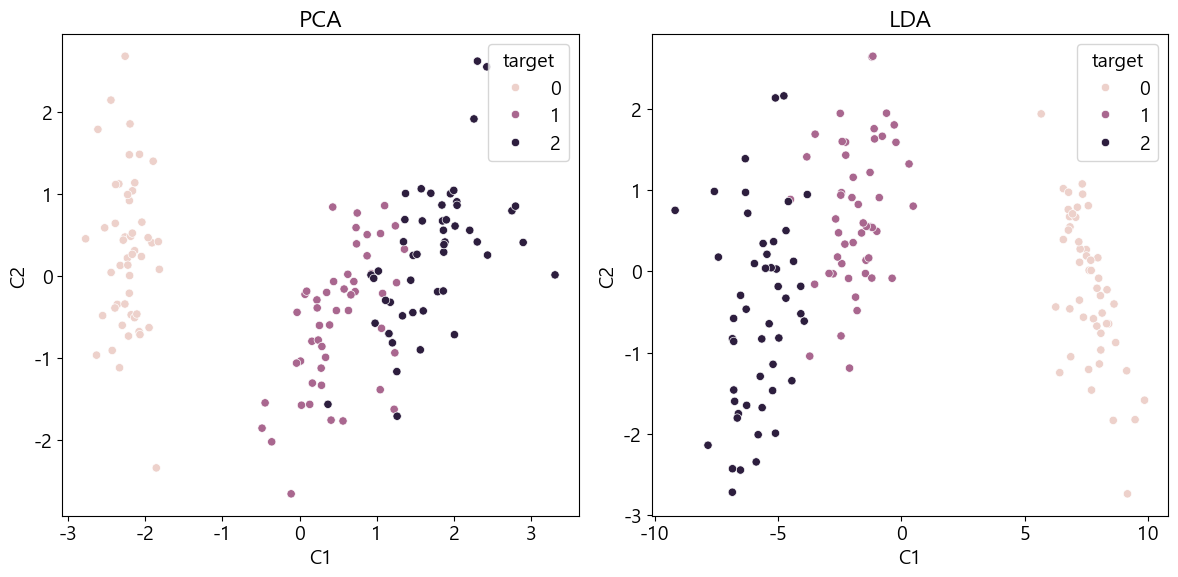

In [14]:
# 시각화
plt.subplot(1,2,1)
sns.scatterplot(data=pca_df, x='C1', y='C2', hue='target')
plt.title("PCA")

plt.subplot(1,2,2)
sns.scatterplot(data=lda_df, x='C1', y='C2', hue='target')
plt.title("LDA")

plt.tight_layout()
plt.show()

In [15]:
# 예측 평가를 위해 데이터를 균일하게 나눈다.
test_df = pd.DataFrame(X)
random_idx = test_df.sample(frac=1).index
train_idx = random_idx[:100]
test_idx = random_idx[100:]

print(train_idx)
print(test_idx)

Index([ 77, 107,  15, 122, 120, 100,  40,  93,  53, 118,  70,   3,  97,  13,
       134,  63,  66,  81,  68,  20,  49, 112, 148,  72,  57,  74,   4,  32,
       105,  26,  89,  59,  51,  16,  73, 117,  62,  36,  82, 133,  44,  80,
       113,   7,  29,  90,  19, 119, 115, 124, 138,  22,  58, 143,  41,  79,
        37, 135,  87, 131,  34,  96, 102,  23,  39, 147, 101,  28,   9,   5,
        71,  54,  98,  47,  18,  43,  14, 104, 125,  24,  94, 142,   2,  35,
       145, 132,   0,   8, 139,  42,  45, 128, 137,  76,  55,  78,  67, 136,
         6,  12],
      dtype='int64')
Index([103,  99,  95,  84, 121,  27,  56,  17,  25,  10, 114, 108, 127, 110,
        91,  48, 129, 141,  60,  61,  75,  38,  65, 111,  33,  85, 116,  88,
        30,  92,   1,  86, 149, 126, 123, 106, 130,  21,  50, 144, 140, 146,
        83,  64,  11,  31, 109,  52,  69,  46],
      dtype='int64')


In [24]:
# 데이터를 나눈다.
pca_train_X = X_pca[train_idx,:]
pca_train_y = y[train_idx]
pca_test_X = X_pca[test_idx,:]
pca_test_y = y[test_idx]

lda_train_X = X_lda[train_idx,:]
lda_train_y = y[train_idx]
lda_test_X = X_lda[test_idx,:]
lda_test_y = y[test_idx]

In [25]:
pca_model = LogisticRegression()
lda_model = LogisticRegression()

pca_model.fit(pca_train_X, pca_train_y)
lda_model.fit(lda_train_X, lda_train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
# 예측한다.
pca_pred = pca_model.predict(pca_test_X)
lda_pred = lda_model.predict(lda_test_X)

In [28]:
pca_accuracy = accuracy_score(pca_pred, pca_test_y)
lda_accuracy = accuracy_score(lda_pred, lda_test_y)

pca_f1 = f1_score(pca_pred, pca_test_y, average='macro')
lda_f1 = f1_score(lda_pred, lda_test_y, average='macro')

print(f'pca accuracy : {pca_accuracy}')
print(f'lda accuracy : {lda_accuracy}')
print(f'pca f1 : {pca_f1}')
print(f'lda f1 : {lda_f1}')

pca accuracy : 0.86
lda accuracy : 0.98
pca f1 : 0.8738738738738739
lda f1 : 0.981929181929182


### t-SNE

In [46]:
# 학생 필기 데이터
from sklearn.datasets import load_digits
import matplotlib as mpl

In [47]:
digits = load_digits()
X = digits.data
y = digits.target

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
# 차원 축소
pca = PCA(n_components=2, random_state=42)
lda = LinearDiscriminantAnalysis(n_components=2)
tsne = TSNE(n_components=2,random_state=42)

X_pca = pca.fit_transform(X_scaled)
X_lda = lda.fit_transform(X_scaled,y)
X_tsne = tsne.fit_transform(X_scaled)

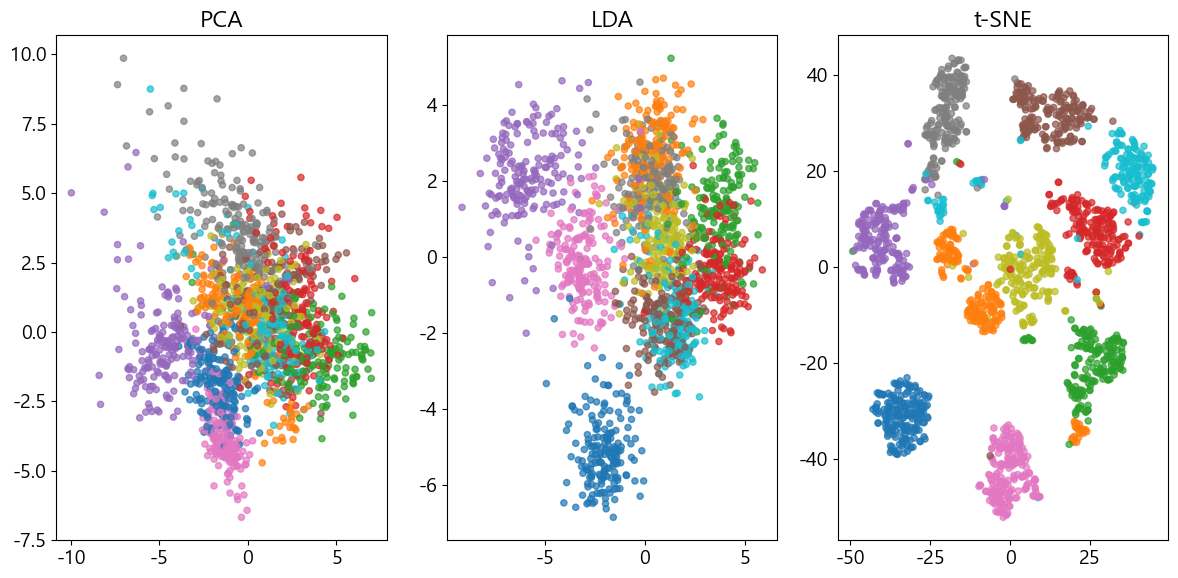

In [62]:
# 시각화
cmap = mpl.colormaps.get_cmap('tab10').resampled(10)

plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap=cmap, alpha=0.7, s=20)
plt.title('PCA')

plt.subplot(1,3,2)
plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap=cmap, alpha=0.7, s=20)
plt.title('LDA')

plt.subplot(1,3,3)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap=cmap, alpha=0.7, s=20)
plt.title('t-SNE')

plt.tight_layout()
plt.show()